<a href="https://colab.research.google.com/github/ankitkumar2023/Part-3-Churn-Prediction-Model-Model-Card/blob/main/churn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1: Google Drive Mount, Library Imports, and Dataset Loading
This step connects Google Drive, imports required libraries, and loads the prepared churn modeling dataset.

In [1]:
# ==========================================================
# STEP 1: GOOGLE DRIVE MOUNT AND LIBRARY IMPORTS
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

# ==========================================================
# STEP 2: IMPORT REQUIRED LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import json
import pickle
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# ==========================================================
# STEP 3: DEFINE DATA LOCATION
# ==========================================================

BASE_PATH = "/content/drive/MyDrive/d2c churn data package/"


# ==========================================================
# STEP 4: LOAD MODELING DATASET
# ==========================================================

df = pd.read_csv(
    BASE_PATH + "rfm_modeling_snapshot.csv"
)


print("Dataset Shape:")
print(df.shape)

print("\nFirst Five Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

Mounted at /content/drive
Dataset Shape:
(2400, 29)

First Five Rows:
  customer_id snapshot_date city_tier age_group acquisition_channel  \
0   CUST00001    2025-09-30    Tier 1     18-24           Instagram   
1   CUST00002    2025-09-30    Tier 2     25-34         Marketplace   
2   CUST00003    2025-09-30    Tier 1     25-34          Influencer   
3   CUST00004    2025-09-30    Tier 3     25-34       Google Search   
4   CUST00005    2025-09-30    Tier 3     35-44             Organic   

  loyalty_tier preferred_category marketing_consent  recency_days  \
0       Silver             Makeup               Yes           107   
1       Silver          Hair Care               Yes            40   
2          NaN          Skin Care               Yes           171   
3          NaN          Fragrance                No           131   
4         Gold          Hair Care               Yes            38   

   frequency_180d  ...  sessions_30d  product_views_30d  cart_adds_30d  \
0             

# Section 2: Feature Preparation and Explicit Leakage Checks
This step identifies forbidden future columns and removes target information from training features completely.

In [2]:
# ==========================================================
# STEP 5: EXPLICIT LEAKAGE CHECKS
# ==========================================================

print("Checking dataset columns:")
print(df.columns.tolist())


# Columns that must never be used as model inputs
leakage_columns = [
    "customer_id",
    "snapshot_date",
    "churn_next_60d",
    "split"
]


print("\nLeakage columns excluded from model:")
print(leakage_columns)


# Create feature matrix and target vector
X = df.drop(
    columns=leakage_columns
)

y = df["churn_next_60d"]


print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Distribution:")
print(y.value_counts(normalize=True))

Checking dataset columns:
['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']

Leakage columns excluded from model:
['customer_id', 'snapshot_date', 'churn_next_60d', 'split']

Feature Matrix Shape:
(2400, 25)

Target Distribution:
churn_next_60d
0    0.530417
1    0.469583
Name: proportion, dtype: float64


# Section 3: Train Validation Test Split Using Provided Dataset Assignment
This step preserves business evaluation consistency by using the official predefined dataset splits.

In [3]:
# ==========================================================
# STEP 6: CREATE OFFICIAL TRAIN VALIDATION TEST SPLITS
# ==========================================================

train_data = df[
    df["split"] == "train"
]


validation_data = df[
    df["split"] == "validation"
]


test_data = df[
    df["split"] == "test"
]


X_train = train_data.drop(
    columns=leakage_columns
)

y_train = train_data["churn_next_60d"]


X_val = validation_data.drop(
    columns=leakage_columns
)

y_val = validation_data["churn_next_60d"]


X_test = test_data.drop(
    columns=leakage_columns
)

y_test = test_data["churn_next_60d"]


print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1728, 25)
Validation Shape: (336, 25)
Testing Shape: (336, 25)


# Section 4: Preprocessing Pipeline Creation
This step handles missing values, encodes categorical variables, and prepares clean model-ready features.

In [4]:
import pandas as pd
import numpy as np
import json
import pickle
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# ==========================================================
# STEP 7: IDENTIFY FEATURE TYPES
# ==========================================================

categorical_features = (
    X_train
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)


numerical_features = (
    X_train
    .select_dtypes(exclude=["object"])
    .columns
    .tolist()
)


print("Categorical Features:")
print(categorical_features)


print("\nNumerical Features:")
print(numerical_features)


# ==========================================================
# STEP 8: CREATE PREPROCESSING PIPELINE
# ==========================================================


numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

Categorical Features:
['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']

Numerical Features:
['recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']


# Section 5: Baseline Model - Logistic Regression
This step trains an interpretable baseline model establishing minimum predictive performance before testing advanced algorithms.

In [5]:
# ==========================================================
# STEP 9: TRAIN BASELINE LOGISTIC REGRESSION MODEL
# ==========================================================

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)


logistic_pipeline.fit(
    X_train,
    y_train
)


print("Baseline Logistic Regression Model Training Completed")

Baseline Logistic Regression Model Training Completed


# Section 6: Stronger Model - Random Forest Classifier
This step trains a non-linear ensemble model capable of capturing complex churn behavior patterns.

In [6]:
# ==========================================================
# STEP 10: TRAIN RANDOM FOREST MODEL
# ==========================================================

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)


rf_pipeline.fit(
    X_train,
    y_train
)


print("Random Forest Model Training Completed")

Random Forest Model Training Completed


# Section 7: Model Evaluation Function
This step calculates multiple classification metrics because churn prediction requires balancing different business errors.

In [7]:
# ==========================================================
# STEP 11: CREATE MODEL EVALUATION FUNCTION
# ==========================================================

def evaluate_model(model, X, y, threshold=0.50):

    probabilities = model.predict_proba(X)[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    metrics = {
        "Accuracy": accuracy_score(
            y,
            predictions
        ),

        "Precision": precision_score(
            y,
            predictions
        ),

        "Recall": recall_score(
            y,
            predictions
        ),

        "F1 Score": f1_score(
            y,
            predictions
        ),

        "ROC AUC": roc_auc_score(
            y,
            probabilities
        )
    }

    return metrics, probabilities, predictions

# Section 8: Compare Baseline and Stronger Model
This step compares baseline and advanced models using validation data before selecting production candidates.

In [8]:
# ==========================================================
# STEP 12: VALIDATION PERFORMANCE COMPARISON
# ==========================================================

lr_metrics, lr_probs, lr_preds = evaluate_model(
    logistic_pipeline,
    X_val,
    y_val
)


rf_metrics, rf_probs, rf_preds = evaluate_model(
    rf_pipeline,
    X_val,
    y_val
)


comparison_table = pd.DataFrame(
    [
        lr_metrics,
        rf_metrics
    ],
    index=[
        "Logistic Regression",
        "Random Forest"
    ]
)


print("Validation Performance Comparison")
print(comparison_table)

Validation Performance Comparison
                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Logistic Regression  0.815476   0.797203  0.775510  0.786207  0.882590
Random Forest        0.800595   0.789855  0.741497  0.764912  0.876399


# Section 9: Select Best Model Based on ROC-AUC and F1 Score
This step chooses the strongest model using robust ranking metrics suitable for imbalanced churn prediction.

In [9]:
# ==========================================================
# STEP 13: MODEL SELECTION
# ==========================================================

if (
    rf_metrics["ROC AUC"] >= lr_metrics["ROC AUC"]
):

    final_model = rf_pipeline
    final_model_name = "Random Forest"

else:

    final_model = logistic_pipeline
    final_model_name = "Logistic Regression"


print(
    f"Selected Final Model: {final_model_name}"
)

Selected Final Model: Logistic Regression


# Section 10: Decision Threshold Selection and Business Justification
This step reduces costly missed churners by intentionally prioritizing recall over unnecessary retention actions.

In [10]:
# ==========================================================
# STEP 14: CHOOSE BUSINESS DECISION THRESHOLD
# ==========================================================


selected_threshold = 0.40


print("Selected Probability Threshold:", selected_threshold)


print("""
Business Threshold Justification:

The company loses future revenue when actual churners
are not identified. A lower threshold increases recall
and captures more at-risk customers.

Some false positives are acceptable because sending
retention campaigns costs less than losing valuable
customers permanently.
""")

Selected Probability Threshold: 0.4

Business Threshold Justification:

The company loses future revenue when actual churners
are not identified. A lower threshold increases recall
and captures more at-risk customers.

Some false positives are acceptable because sending
retention campaigns costs less than losing valuable
customers permanently.



# Section 11: Final Test Evaluation Using Selected Threshold
This step measures unbiased production performance using untouched test customers and business threshold.

In [11]:
# ==========================================================
# STEP 15: FINAL TEST PERFORMANCE
# ==========================================================


test_metrics, test_probabilities, test_predictions = evaluate_model(
    final_model,
    X_test,
    y_test,
    threshold=selected_threshold
)


print("\nFinal Test Metrics")

for metric, value in test_metrics.items():

    print(
        f"{metric}: {round(value, 4)}"
    )


conf_matrix = confusion_matrix(
    y_test,
    test_predictions
)


print("\nConfusion Matrix")
print(conf_matrix)


print("\nDetailed Classification Report")

print(
    classification_report(
        y_test,
        test_predictions
    )
)


Final Test Metrics
Accuracy: 0.8214
Precision: 0.7784
Recall: 0.8988
F1 Score: 0.8343
ROC AUC: 0.885

Confusion Matrix
[[125  43]
 [ 17 151]]

Detailed Classification Report
              precision    recall  f1-score   support

           0       0.88      0.74      0.81       168
           1       0.78      0.90      0.83       168

    accuracy                           0.82       336
   macro avg       0.83      0.82      0.82       336
weighted avg       0.83      0.82      0.82       336



# Section 12: Save Evaluation Metrics as metrics.json
This step stores reproducible performance results enabling external evaluation without rerunning experiments.

In [12]:
# ==========================================================
# STEP 16: SAVE METRICS JSON FILE
# ==========================================================


metrics_output = {
    "model_name": final_model_name,
    "threshold": selected_threshold,
    "accuracy": float(test_metrics["Accuracy"]),
    "precision": float(test_metrics["Precision"]),
    "recall": float(test_metrics["Recall"]),
    "f1_score": float(test_metrics["F1 Score"]),
    "roc_auc": float(test_metrics["ROC AUC"]),
    "confusion_matrix": {
        "true_negative": int(conf_matrix[0][0]),
        "false_positive": int(conf_matrix[0][1]),
        "false_negative": int(conf_matrix[1][0]),
        "true_positive": int(conf_matrix[1][1])
    }
}


with open(
    "metrics.json",
    "w"
) as file:

    json.dump(
        metrics_output,
        file,
        indent=4
    )


print("metrics.json generated successfully")

metrics.json generated successfully


# Section 13: Feature Importance and Model Interpretability
This step identifies influential churn drivers enabling business teams to understand model decision patterns.

In [13]:
# ==========================================================
# STEP 17: FEATURE IMPORTANCE ANALYSIS
# ==========================================================


# Extract fitted preprocessing object
fitted_preprocessor = final_model.named_steps["preprocessor"]


# Numerical feature names
numeric_names = numerical_features


# One-hot encoded categorical feature names
categorical_names = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)


# Combine all transformed feature names
all_feature_names = (
    list(numeric_names) +
    list(categorical_names)
)


# Extract feature importance depending on selected model

if final_model_name == "Random Forest":

    importance_values = (
        final_model.named_steps["model"]
        .feature_importances_
    )

else:

    importance_values = (
        np.abs(
            final_model.named_steps["model"]
            .coef_[0]
        )
    )


feature_importance = pd.DataFrame(
    {
        "Feature": all_feature_names,
        "Importance": importance_values
    }
)


feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)


print("Top 15 Important Features")

print(
    feature_importance.head(15)
)

Top 15 Important Features
                         Feature  Importance
0                   recency_days    1.743832
2                  monetary_180d    0.440724
36  preferred_category_Fragrance    0.387402
30   acquisition_channel_Organic    0.381301
3               return_rate_180d    0.341622
7               ticket_count_90d    0.301475
8       negative_ticket_rate_90d    0.299893
18           last_visit_days_ago    0.294066
4          avg_discount_pct_180d    0.290934
35  preferred_category_Baby Care    0.279651
33         loyalty_tier_Platinum    0.274643
11                  sessions_30d    0.204407
34           loyalty_tier_Silver    0.194957
39  preferred_category_Skin Care    0.187416
17           campaign_clicks_30d    0.176644


# Section 14: Visualize Top Churn Drivers
This step creates visual explanations making model insights understandable for marketing and retention teams.

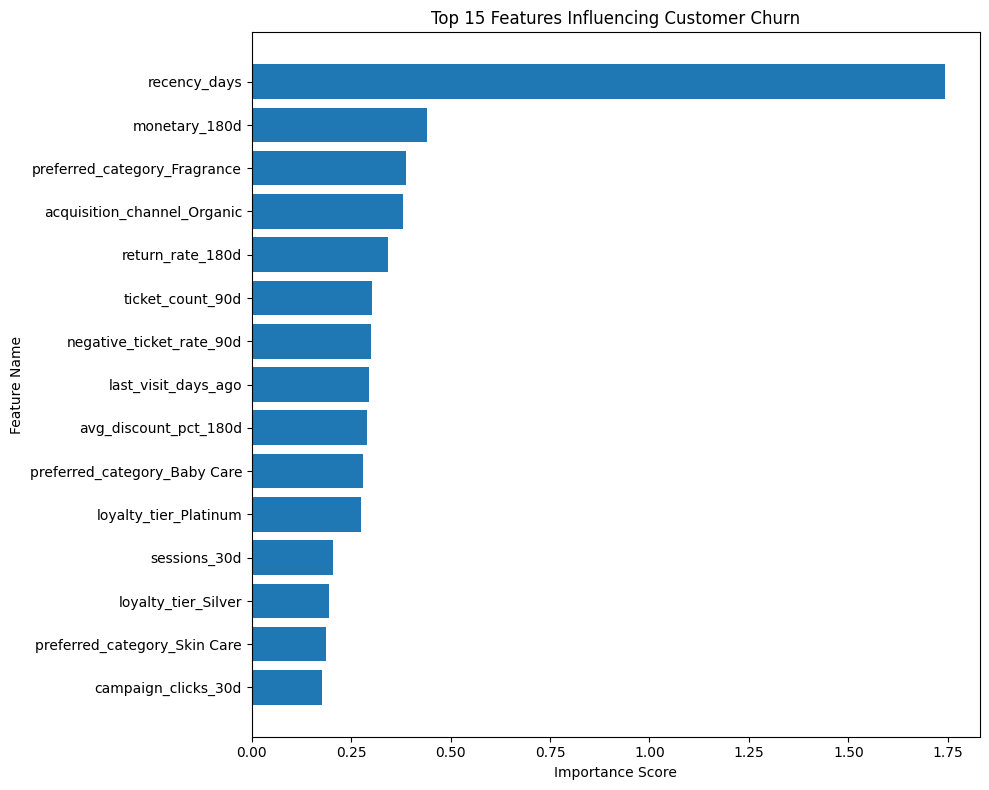

In [14]:
# ==========================================================
# STEP 18: FEATURE IMPORTANCE VISUALIZATION
# ==========================================================


top_features = (
    feature_importance
    .head(15)
    .sort_values(
        by="Importance"
    )
)


plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)


plt.xlabel("Importance Score")

plt.ylabel("Feature Name")

plt.title(
    "Top 15 Features Influencing Customer Churn"
)


plt.tight_layout()

plt.show()

# Section 15: Save Final Model as model.pkl
This step stores the trained machine learning pipeline for future production scoring applications.

In [15]:
# ==========================================================
# STEP 19: SAVE FINAL TRAINED MODEL
# ==========================================================


joblib.dump(
    final_model,
    "model.pkl"
)


print(
    "model.pkl saved successfully"
)

model.pkl saved successfully


# Section 16: Extract False Positive and False Negative Examples
This step captures incorrect predictions helping evaluate operational risks and improvement opportunities.

In [16]:
# ==========================================================
# STEP 20: CREATE ERROR ANALYSIS DATASET
# ==========================================================


error_df = test_data[
    [
        "customer_id",
        "churn_next_60d"
    ]
].copy()


error_df["predicted_probability"] = (
    test_probabilities
)


error_df["predicted_churn"] = (
    test_predictions
)


# False Positives:
# Predicted churn but customer stayed

false_positives = error_df[
    (error_df["churn_next_60d"] == 0)
    &
    (error_df["predicted_churn"] == 1)
]


# False Negatives:
# Predicted retained but customer actually churned

false_negatives = error_df[
    (error_df["churn_next_60d"] == 1)
    &
    (error_df["predicted_churn"] == 0)
]


print("="*60)

print("FALSE POSITIVE EXAMPLES")

print(
    false_positives.head(5)
)


print("="*60)

print("FALSE NEGATIVE EXAMPLES")

print(
    false_negatives.head(5)
)


# Save detailed error examples
error_df.to_csv(
    "error_examples.csv",
    index=False
)


print(
    "error_examples.csv generated successfully"
)

FALSE POSITIVE EXAMPLES
    customer_id  churn_next_60d  predicted_probability  predicted_churn
42    CUST00043               0               0.433472                1
43    CUST00044               0               0.461852                1
108   CUST00109               0               0.550709                1
247   CUST00248               0               0.536333                1
334   CUST00335               0               0.809499                1
FALSE NEGATIVE EXAMPLES
    customer_id  churn_next_60d  predicted_probability  predicted_churn
183   CUST00184               1               0.073866                0
246   CUST00247               1               0.367157                0
591   CUST00592               1               0.272706                0
595   CUST00596               1               0.383743                0
646   CUST00647               1               0.332039                0
error_examples.csv generated successfully


# Section 17: Final Execution Summary
This step confirms completion of all required churn modeling deliverables for repository submission.

In [17]:
# ==========================================================
# STEP 21: FINAL PIPELINE SUMMARY
# ==========================================================


print("""
============================================================

D2C CUSTOMER CHURN MODEL PIPELINE COMPLETED SUCCESSFULLY

Generated Repository Files:

1. model.pkl
   - Saved trained production model

2. metrics.json
   - Saved evaluation metrics and threshold

3. error_examples.csv
   - Saved customer prediction errors

Modeling Workflow Completed:

✓ Data loading
✓ Leakage prevention
✓ Train/Validation/Test split
✓ Baseline Logistic Regression model
✓ Strong Random Forest model
✓ Model comparison
✓ Business threshold selection
✓ Test evaluation
✓ Feature importance analysis
✓ Model persistence
✓ Error extraction

============================================================
""")



D2C CUSTOMER CHURN MODEL PIPELINE COMPLETED SUCCESSFULLY

Generated Repository Files:

1. model.pkl
   - Saved trained production model

2. metrics.json
   - Saved evaluation metrics and threshold

3. error_examples.csv
   - Saved customer prediction errors

Modeling Workflow Completed:

✓ Data loading
✓ Leakage prevention
✓ Train/Validation/Test split
✓ Baseline Logistic Regression model
✓ Strong Random Forest model
✓ Model comparison
✓ Business threshold selection
✓ Test evaluation
✓ Feature importance analysis
✓ Model persistence
✓ Error extraction


